# 03 — ResNet Features

Pre-train a ResNet18 classifier on the 52-letter classification task (A–Z, a–z), freeze the backbone, and extract 512-dimensional feature vectors for every glyph in every font.

**Input**: `data/processed/glyphs/{stem}.npz`, `data/processed/manifest.csv`, `data/processed/fonts_catalog.csv`.
**Output**: `data/processed/features/{stem}.npz`, `data/processed/features_manifest.csv`.
**Model**: `data/processed/models/resnet_classifier.pt`.

In [1]:
import json
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("kern")

_cwd = Path.cwd().resolve()
if (_cwd / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
GLYPH_DIR = DATA_PROCESSED / "glyphs"
FEATURE_DIR = DATA_PROCESSED / "features"
MODEL_DIR = DATA_PROCESSED / "models"
GLYPH_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 256
NUM_CLASSES = 52
LATIN_52 = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
FEATURE_DIM = 512
NPZ_CACHE_SIZE = 256

# Training
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MAX_EPOCHS = 20
EARLY_STOP_PATIENCE = 5
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info("Device: %s", DEVICE)
log.info("Root: %s", PROJECT_ROOT)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

2026-07-22 02:30:28,071 | INFO | Device: cuda
2026-07-22 02:30:28,072 | INFO | Root: C:\Users\angel\OneDrive\Desktop\Kern


In [2]:
# Load manifest + catalog
manifest = pd.read_csv(DATA_PROCESSED / "manifest.csv")
catalog = pd.read_csv(DATA_PROCESSED / "fonts_catalog.csv")
ok = manifest[manifest["status"] == "ok"].reset_index(drop=True)
ok = ok.merge(catalog[["stem", "family"]], on="stem", how="left")
log.info("OK fonts: %d | Families: %d", len(ok), ok["family"].nunique())

samples = []  # list of (stem, glyph_idx_in_file, label)
stems_info = {}  # stem -> {family, filepath, n_glyphs}

for _, row in tqdm(ok.iterrows(), total=len(ok), desc="Indexing glyphs"):
    stem = row["stem"]
    z = np.load(GLYPH_DIR / f"{stem}.npz")
    idxs = z["glyph_indices"]  # (N,) int32
    n = len(idxs)
    stems_info[stem] = {
        "family": row["family"],
        "filepath": str(GLYPH_DIR / f"{stem}.npz"),
        "n_glyphs": n,
    }
    for i in range(n):
        samples.append((stem, i, int(idxs[i])))

log.info("Total samples: %d", len(samples))

2026-07-22 02:30:28,192 | INFO | OK fonts: 7263 | Families: 1861


Indexing glyphs:   0%|          | 0/7263 [00:00<?, ?it/s]

2026-07-22 02:30:51,788 | INFO | Total samples: 377676


In [3]:
# Split by family
all_families = []
for stem, _, _ in samples:
    all_families.append(stems_info[stem]["family"])

family_names = sorted(set(all_families))
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(family_names)

n = len(family_names)
n_train = int(n * 0.8)
n_val = int(n * 0.1)

train_families = set(family_names[:n_train])
val_families = set(family_names[n_train:n_train + n_val])
test_families = set(family_names[n_train + n_val:])

train_mask = [f in train_families for f in all_families]
val_mask = [f in val_families for f in all_families]
test_mask = [f in test_families for f in all_families]

train_samples = [s for s, m in zip(samples, train_mask) if m]
val_samples = [s for s, m in zip(samples, val_mask) if m]
test_samples = [s for s, m in zip(samples, test_mask) if m]

log.info("Families: %d train / %d val / %d test", len(train_families), len(val_families), len(test_families))
log.info("Samples: %d train / %d val / %d test", len(train_samples), len(val_samples), len(test_samples))

2026-07-22 02:30:51,927 | INFO | Families: 1488 train / 186 val / 187 test
2026-07-22 02:30:51,928 | INFO | Samples: 299416 train / 37388 val / 40872 test


In [4]:
class LazyGlyphDataset(Dataset):
    """Loads glyph images on-demand from .npz files with a small LRU cache."""
    def __init__(self, samples, stems_info, cache_size=NPZ_CACHE_SIZE):
        self.samples = samples  # (stem, local_idx, label)
        self.stems_info = stems_info
        self.cache_size = cache_size
        self._cache = {}  # stem -> glyph_images ndarray

    def __len__(self):
        return len(self.samples)

    def _load_stem(self, stem):
        if stem in self._cache:
            return self._cache[stem]
        z = np.load(self.stems_info[stem]["filepath"])
        imgs = z["glyph_images"]  # (N, 256, 256) uint8
        # Evict oldest if cache full
        if len(self._cache) >= self.cache_size:
            self._cache.pop(next(iter(self._cache)))
        self._cache[stem] = imgs
        return imgs

    def __getitem__(self, idx):
        stem, local_idx, label = self.samples[idx]
        imgs = self._load_stem(stem)
        img = imgs[local_idx]  # (256, 256) uint8
        # Preprocess: (256,256) uint8 -> (3,256,256) float32 normed
        f32 = img.astype(np.float32, copy=False)
        three_ch = np.stack([f32, f32, f32], axis=0)  # (3, H, W)
        normed = (three_ch - 0.5) / 0.5
        return torch.from_numpy(normed), label

train_ds = LazyGlyphDataset(train_samples, stems_info)
val_ds = LazyGlyphDataset(val_samples, stems_info)
test_ds = LazyGlyphDataset(test_samples, stems_info)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
log.info("DataLoaders ready")

2026-07-22 02:30:51,935 | INFO | DataLoaders ready


In [5]:
def build_resnet18(num_classes: int) -> nn.Module:
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

In [6]:
CHECKPOINT_PATH = MODEL_DIR / "resnet_checkpoint.pt"
BEST_MODEL_PATH = MODEL_DIR / "resnet_classifier.pt"
HISTORY_PATH = MODEL_DIR / "resnet_training_history.csv"

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    desc = "Train" if is_train else "Eval"
    for x, y in tqdm(loader, desc=desc, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        if is_train:
            optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(y)
        total_correct += (out.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss / total, total_correct / total


# --- Resume or start fresh ---
start_epoch = 1
history = []
best_val_loss = float("inf")
patience_counter = 0

if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, weights_only=False, map_location="cpu")
    model = build_resnet18(NUM_CLASSES)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_val_loss = ckpt["best_val_loss"]
    patience_counter = ckpt["patience_counter"]
    history = ckpt.get("history", [])
    log.info("Resumed from epoch %d (best val_loss=%.4f)", ckpt["epoch"], best_val_loss)
else:
    model = build_resnet18(NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    log.info("Starting fresh. Model: %d parameters", count_params(model))

criterion = nn.CrossEntropyLoss()

for epoch in range(start_epoch, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
                    "train_acc": train_acc, "val_acc": val_acc})
    log.info("Epoch %3d | train_loss=%.4f val_loss=%.4f | train_acc=%.3f val_acc=%.3f",
             epoch, train_loss, val_loss, train_acc, val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        patience_counter += 1

    # Save checkpoint every epoch
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "patience_counter": patience_counter,
        "history": history,
    }, CHECKPOINT_PATH)

    if patience_counter >= EARLY_STOP_PATIENCE:
        log.info("Early stopping at epoch %d", epoch)
        break

test_loss, test_acc = run_epoch(test_loader, model, criterion)
log.info("Test: loss=%.4f acc=%.3f", test_loss, test_acc)

pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)
log.info("Training history saved to %s", HISTORY_PATH)

if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()
    log.info("Checkpoint removed (training complete)")

2026-07-22 02:30:53,585 | INFO | Starting fresh. Model: 11203188 parameters


Train:   0%|          | 0/4679 [00:00<?, ?it/s]

Eval:   0%|          | 0/585 [00:00<?, ?it/s]

2026-07-22 03:08:52,591 | INFO | Epoch   1 | train_loss=0.2155 val_loss=0.1104 | train_acc=0.945 val_acc=0.969


Train:   0%|          | 0/4679 [00:00<?, ?it/s]

...

Train:   0%|          | 0/4679 [00:00<?, ?it/s]

Eval:   0%|          | 0/585 [00:00<?, ?it/s]

2026-07-22 07:31:52,838 | INFO | Epoch   8 | train_loss=0.0493 val_loss=0.0917 | train_acc=0.983 val_acc=0.980
2026-07-22 07:31:53,008 | INFO | Early stopping at epoch 8


Eval:   0%|          | 0/639 [00:00<?, ?it/s]

2026-07-22 07:32:53,340 | INFO | Test: loss=0.1288 acc=0.971
2026-07-22 07:32:53,349 | INFO | Training history saved to C:\Users\angel\OneDrive\Desktop\Kern\data\processed\models\resnet_training_history.csv
2026-07-22 07:32:53,368 | INFO | Checkpoint removed (training complete)


In [7]:
# Build backbone: load best classifier, strip fc layer
backbone = build_resnet18(NUM_CLASSES)
backbone.load_state_dict(torch.load(BEST_MODEL_PATH, weights_only=True, map_location="cpu"))
backbone.fc = nn.Identity()  # output → (B, 512)
backbone.eval().to(DEVICE)
log.info("Backbone ready: output dim=%d", FEATURE_DIM)

2026-07-22 07:32:53,611 | INFO | Backbone ready: output dim=512


In [8]:
# Resume manifest if exists, or start fresh
manifest_path = DATA_PROCESSED / "features_manifest.csv"
if manifest_path.exists():
    feat_manifest = pd.read_csv(manifest_path).to_dict("records")
    done_stems = set(r["stem"] for r in feat_manifest)
    log.info("Resuming feature extraction: %d already done", len(done_stems))
else:
    feat_manifest = []
    done_stems = set()

remaining = ok[~ok["stem"].isin(done_stems)]
log.info("Remaining: %d fonts", len(remaining))

for _, row in tqdm(remaining.iterrows(), total=len(remaining), desc="Extracting features"):
    stem = row["stem"]
    out_path = FEATURE_DIR / f"{stem}.npz"
    try:
        z = np.load(GLYPH_DIR / f"{stem}.npz")
        imgs = z["glyph_images"]
        indices = z["glyph_indices"]
        names = z["glyph_names"]

        x = imgs.astype(np.float32, copy=False)
        x = np.stack([x, x, x], axis=1)  # (N, 3, 256, 256)
        x = (x - 0.5) / 0.5
        x_t = torch.from_numpy(x).to(DEVICE)

        with torch.no_grad():
            features = backbone(x_t).cpu().numpy()  # (N, 512)

        np.savez_compressed(
            out_path,
            features=features,
            glyph_names=np.array(names),
            glyph_indices=np.array(indices, dtype=np.int32),
            font_stem=stem,
        )
        feat_manifest.append({"stem": stem, "feature_path": str(out_path),
                              "num_glyphs": len(imgs), "status": "ok", "error": None})
    except Exception as e:
        log.error("Feature extraction failed: %s — %s", stem, e)
        feat_manifest.append({"stem": stem, "feature_path": None,
                              "num_glyphs": 0, "status": "failed", "error": str(e)})

feat_df = pd.DataFrame(feat_manifest)
feat_df.to_csv(manifest_path, index=False)
log.info("Done — %d ok / %d failed",
         (feat_df["status"] == "ok").sum(),
         (feat_df["status"] == "failed").sum())

2026-07-22 07:32:53,624 | INFO | Remaining: 7263 fonts


Extracting features:   0%|          | 0/7263 [00:00<?, ?it/s]

2026-07-22 07:45:15,526 | INFO | Done — 7263 ok / 0 failed


In [9]:
print("=" * 55)
print("SUMMARY")
print("=" * 55)

feat_df = pd.read_csv(DATA_PROCESSED / "features_manifest.csv")
ok_f = feat_df[feat_df["status"] == "ok"]
fail_f = feat_df[feat_df["status"] == "failed"]
total_glyphs = ok_f["num_glyphs"].sum() if "num_glyphs" in ok_f else 0

print(f"\n  Feature files          : {len(ok_f)} ok / {len(fail_f)} failed")
print(f"  Total glyphs processed : {total_glyphs}")

if len(ok_f) > 0:
    sample = np.load(FEATURE_DIR / f"{ok_f.iloc[0]['stem']}.npz")
    print(f"\n  Sample ({ok_f.iloc[0]['stem']}):")
    print(f"    features shape: {sample['features'].shape}")
    print(f"    feature range: [{sample['features'].min():.3f}, {sample['features'].max():.3f}]")
    print(f"    names: {list(sample['glyph_names'])}")

if len(fail_f) > 0:
    print(f"\n  Failure reasons:")
    for err, cnt in fail_f["error"].value_counts().items():
        print(f"    {err}: {cnt}")

print("\n" + "=" * 55)

SUMMARY

  Feature files          : 7263 ok / 0 failed
  Total glyphs processed : 377676

  Sample (Roboto_100):
    features shape: (52, 512)
    feature range: [0.000, 4.895]
    names: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z')]



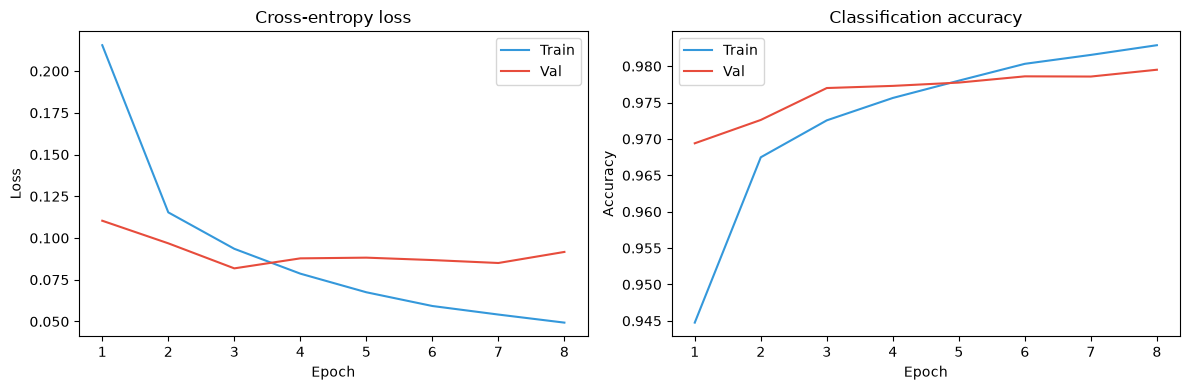

Val acc:  0.980
Train acc: 0.983
Epochs trained: 8


In [10]:
import matplotlib.pyplot as plt

hist_path = MODEL_DIR / "resnet_training_history.csv"
if hist_path.exists():
    h = pd.read_csv(hist_path)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h["epoch"], h["train_loss"], label="Train", color="#3498db")
    axes[0].plot(h["epoch"], h["val_loss"], label="Val", color="#e74c3c")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].set_title("Cross-entropy loss")

    axes[1].plot(h["epoch"], h["train_acc"], label="Train", color="#3498db")
    axes[1].plot(h["epoch"], h["val_acc"], label="Val", color="#e74c3c")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].set_title("Classification accuracy")
    plt.tight_layout()
    plt.show()
    print(f"Val acc:  {h['val_acc'].max():.3f}")
    print(f"Train acc: {h['train_acc'].max():.3f}")
    print(f"Epochs trained: {len(h)}")